In [1]:
import duckdb
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

pl.Config(fmt_str_lengths=1000, tbl_width_chars=1000)
pl.Config(tbl_rows=10)

In [2]:
conn = duckdb.connect("amfi.duckdb")

In [3]:
# conn.execute(
#     """
# DROP VIEW IF EXISTS fund_house_v;
# DROP VIEW IF EXISTS scheme_v;
# DROP VIEW IF EXISTS scheme_document_v;
# DROP VIEW IF EXISTS scheme_aum_v;
# DROP VIEW IF EXISTS nav_plan_details_v;
# DROP VIEW IF EXISTS nav_v;
#     """
# ).pl()

In [4]:
conn.execute(
    """
    WITH nav AS (
        SELECT distinct sd_id
        FROM nav_v
    )
    SELECT np.sd_id np_sd_id, n.sd_id nav_sd_id
    FROM nav_plan_details_v np
    FULL OUTER JOIN nav n USING (sd_id)
    WHERE np.sd_id IS NULL OR n.sd_id IS NULL
    """
).pl()

np_sd_id,nav_sd_id
i32,i32


In [5]:
conn.execute(
    """
    WITH np AS (
        SELECT distinct fund_house
        FROM nav_plan_details_v
    )
    SELECT np.fund_house np_fund_house, fh.fund_house fh_fund_house
    FROM np
    FULL OUTER JOIN fund_house_v fh USING (fund_house)
    WHERE np.fund_house IS NULL OR fh.fund_house IS NULL
    """
).pl()

np_fund_house,fh_fund_house
str,str
null,"""AlphaGrep Mutual Fund"""


In [6]:
# growth_sd_ids = [118668, 119063, 119574, 119066, 119065, 120784, 120766, 120771, 101834, 149669]
# direct_sd_ids = [119063, 119574, 103633, 101834]
conn.execute(
    """
    CREATE OR REPLACE VIEW plans_active_v AS
    WITH plans AS (
        SELECT fund_house, scheme, plan, sd_id
            , NOT regexp_matches(scheme, '(?i)(deactivate|closed 1|closed|not to use)') is_in_use
            , NOT regexp_matches(
                plan, '(?i)(unclaimed|bonus option|provident fund|wholesale|bonus)'
            ) AS is_retail
            , (
                plan ILIKE '%no lock in%'
                OR NOT EXISTS (
                    SELECT 1
                    FROM nav_plan_details_v p2
                    WHERE p2.scheme = npd.scheme
                    AND p2.plan ILIKE '%no lock in%'
                )
            ) AS is_not_lockin
            , plan ILIKE '%etf%' AND NOT regexp_matches(plan, '(?i)(fund of fund|fof)') is_etf
            , regexp_matches(plan, '(?i)(growth|cumulative)') AND plan NOT ILIKE '%growth%fund%' is_growth
            , plan ILIKE '%direct%' AND plan NOT ILIKE '%indirect'  is_direct
        FROM nav_plan_details_v npd
    ),
    nav AS (
        SELECT sd_id, min(date) start_date, max(date) latest_date, arg_max(nav, date) latest_nav
        from nav_v
        GROUP BY sd_id
    )
    SELECT fh.fund_house_id, fh.fund_house
        , sc.scheme_id, sc.scheme
        , p.sd_id, plan
        , sc.scheme_type
        , lower(regexp_replace(
            CASE
                WHEN sc.scheme_category LIKE '%-%'
                    THEN trim(split_part(sc.scheme_category, '-', 1))
                ELSE trim(sc.scheme_category)
            END,
            '(?i)\s*scheme$',
            ''
        )) AS category
        -- Subcategory
        , CASE
            WHEN sc.scheme_category LIKE '%-%'
                THEN lower(
                    trim(
                        regexp_replace(
                            split_part(sc.scheme_category, '-', 2),
                            '(?i)\s*fund$',
                            ''
                        )
                    )
                )
            ELSE NULL
        END AS subcategory
        , sa.aum
        , sc.launch_date, n.start_date, n.latest_date, n.latest_nav
        , p.is_in_use, p.is_not_lockin, p.is_retail, p.is_etf, p.is_growth, p.is_direct
    FROM plans p
    INNER JOIN nav n USING (sd_id)
    INNER JOIN fund_house_v fh USING (fund_house)
    LEFT JOIN scheme_v sc USING (scheme)
    LEFT JOIN scheme_aum_v sa USING (plan)
    WHERE TRUE
        AND latest_date > current_date - 10
    """
).pl()

Count
i64


In [7]:
conn.execute(
    """
    SELECT count(*)
        , count(DISTINCT CASE WHEN start_date <= '2020-01-01' THEN scheme_id END) schemes_2020
        , count(DISTINCT CASE WHEN start_date <= '2015-01-01' THEN scheme_id END) schemes_2015
    FROM plans_active
    """
).pl()

count_star(),schemes_2020,schemes_2015
i64,i64,i64
8723,860,569


In [8]:
conn.execute(
    """
    SELECT scheme, sd_id, plan
        , launch_date, start_date, latest_date, latest_nav
        , is_in_use, is_not_lockin, is_retail, is_etf, is_growth, is_direct
    FROM plans_active
    WHERE scheme_id = 293
    ORDER by latest_nav DESC
    """
).pl()

scheme,sd_id,plan,launch_date,start_date,latest_date,latest_nav,is_in_use,is_not_lockin,is_retail,is_etf,is_growth,is_direct
str,i32,str,date,date,date,f64,bool,bool,bool,bool,bool,bool
"""UTI Retirement Fund""",120766,"""UTI Retirement Fund- Direct Plan""",1994-12-26,2013-01-02,2026-04-13,53.6245,true,true,true,false,false,true
"""UTI Retirement Fund""",100682,"""UTI Retirement Fund - Regular Plan""",1994-12-26,2010-01-04,2026-04-13,49.4839,true,true,true,false,false,false


In [9]:
# check if any schemes will be missed
conn.execute(
    """
    CREATE OR REPLACE TABLE plans AS
    WITH candidate_plans AS (
        SELECT *,
               (is_in_use AND is_retail AND is_not_lockin 
                AND (is_etf OR (is_growth AND is_direct))) AS is_preferred
        FROM plans_active_v
        WHERE scheme_type <> 'Close Ended'
    ),
    ranked_plans AS (
        SELECT *,
               ROW_NUMBER() OVER (
                   PARTITION BY scheme_id
                   ORDER BY is_preferred DESC
                       , latest_nav DESC, latest_date DESC, start_date DESC
                       , is_in_use DESC, is_not_lockin DESC, is_retail DESC
                       , is_growth DESC, is_direct DESC
               ) AS rn
        FROM candidate_plans
    )
    SELECT fund_house_id, fund_house
        , scheme_id, scheme
        , sd_id, plan
        , scheme_type, r.category, r.subcategory, tax
        , aum, launch_date, start_date, latest_date, latest_nav
        , is_in_use, is_not_lockin, is_retail, is_etf, is_growth, is_direct	
    FROM ranked_plans r
    LEFT JOIN tax_cat t
    ON (r.category IS NOT DISTINCT FROM t.category)
        AND (r.subcategory IS NOT DISTINCT FROM t.subcategory)
    WHERE rn = 1
    ORDER BY scheme_id;
    """
).pl()

Count
i64
2047


In [10]:
# check if any schemes will be missed
conn.execute(
    """
    WITH plans_active AS (
        SELECT distinct fund_house_id, fund_house
            , scheme_id, scheme
        FROM plans_active_v
        WHERE scheme_type <> 'Close Ended'
    )
    SELECT a.*
    FROM plans_active a
    LEFT JOIN plans p USING (scheme_id)
    WHERE p.scheme_id IS NULL
    """
).pl()

fund_house_id,fund_house,scheme_id,scheme
i32,str,i32,str


In [11]:
conn.execute(
    """
    CREATE OR REPLACE TABLE tax_cat AS
    WITH cat AS (
        SELECT distinct category, subcategory
        FROM plans
    )
    SELECT category, subcategory
        , CASE
            WHEN category in ('debt', 'income', 'money market') THEN 0.3
            WHEN category in ('elss', 'equity') THEN 0.125
            WHEN category = 'hybrid' AND subcategory IN (
                    'aggressive hybrid', 'arbitrage', 'equity savings'
                ) THEN 0.125
            WHEN category = 'hybrid' THEN 0.2
            WHEN category = 'other' AND subcategory IN (
                    'fof domestic', 'index funds'
                ) THEN 0.125
            WHEN category = 'other' THEN 0.2
            WHEN category = 'solution oriented' THEN 0.125
        END AS tax
    FROM cat
    ORDER BY category, subcategory
    """
).pl()

Count
i64
44


In [12]:
imp_sd_ids = (120323, 140347, 122639, 118955, 118950, 118989, 120716, 143341, 147622, 130503, 147623, 148815)
imp_sd_ids = str(imp_sd_ids)
inc_arb_ids = (102140,118410,120313,129197,130543,130493,131898,132989,147889,150822)
inc_arb_ids = str(inc_arb_ids)


conn.execute(
    """
    SELECT *
    FROM plans
    WHERE TRUE
        -- AND plan ilike '%edelweiss%%'
        -- AND plan NOT ILIKE '%income%plus%'
        -- AND category = 'debt'
    ORDER BY start_date
    """
).pl()

# 120323 - ICICI Value
# 140347 - Edelweiss Equity Savings
# 122639 - PPFAS Flexi
# 118955 - HDFC Flexi
# 118950 - HDFC Focused
# 118989 - HDFC Mid
# 120716 - UTI N50
# 143341 - UTI NN50
# 147622 - Mo Mid 150
# 130503 - HDFC Small
# 147623 - MoSmall 250
# 148815 - ABSL Small 50

fund_house_id,fund_house,scheme_id,scheme,sd_id,plan,scheme_type,category,subcategory,tax,aum,launch_date,start_date,latest_date,latest_nav,is_in_use,is_not_lockin,is_retail,is_etf,is_growth,is_direct
i32,str,i32,str,i32,str,str,str,str,"decimal[4,3]",f64,date,date,date,f64,bool,bool,bool,bool,bool,bool
16,"""JM Financial Mutual Fund""",489,"""JM Liquid Fund - Daily Dividend Option""",101078,"""JM Liquid Fund (Regular) - Daily IDCW""","""Open Ended""","""debt""","""liquid""",0.300,748.79,1997-12-23,2010-01-01,2026-04-21,10.4302,true,true,true,false,false,false
20,"""ICICI Prudential Mutual Fund""",538,"""ICICI Prudential Short Term Fund - Div. Option""",101165,"""ICICI Prudential Short Term Fund - Monthly IDCW""","""Open Ended""","""debt""","""short duration""",0.300,3335.93,2001-11-30,2010-01-01,2026-04-21,12.1357,true,true,true,false,false,false
16,"""JM Financial Mutual Fund""",606,"""JM Medium to Long Duration Fund Growth - Bonus Option""",101181,"""JM Medium to Long Duration Fund (Regular) - Bonus Option- Principal Units""","""Open Ended""","""debt""","""medium to long duration""",0.300,6.96,2013-01-01,2010-01-01,2026-04-21,25.9875,true,true,false,false,false,false
16,"""JM Financial Mutual Fund""",678,"""JM Liquid Fund - Bonus Option""",101549,"""JM Liquid Fund (Regular) - Bonus Option - Principal Units""","""Open Ended""","""debt""","""liquid""",0.300,18.66,2002-08-17,2010-01-01,2026-04-21,23.9282,true,true,false,false,false,false
48,"""Bandhan Mutual Fund""",3564,"""Bandhan Money Market Fund""",108757,"""BANDHAN Money Market Fund - Regular Plan - Monthly IDCW""","""Open Ended""","""debt""","""money market""",0.300,204.35,2003-02-18,2010-01-01,2026-04-21,10.3389,true,true,true,false,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
84,"""Choice Mutual Fund""",14457,"""Choice Nifty Next 50 Index Fund""",154304,"""Choice Nifty Next 50 Index Fund - Direct Plan Growth""","""Open Ended""","""other""","""index funds""",0.125,null,2026-03-19,2026-04-09,2026-04-21,11.0143,true,true,true,false,true,true
47,"""Edelweiss Mutual Fund""",14462,"""Edelweiss Nifty LargeMidcap250 Plus 8-13yr G-Sec 70:30 Index Fund""",154310,"""Edelweiss Nifty LargeMidcap 250 Plus 8-13 yr G-Sec 70-30 Index Fund Direct Plan Growth""","""Open Ended""","""other""","""index funds""",0.125,null,2026-03-18,2026-04-09,2026-04-21,10.6358,true,true,true,false,true,true
55,"""Motilal Oswal Mutual Fund""",14465,"""Motilal Oswal BSE Top 10 Banks ETF""",154322,"""Motilal Oswal BSE Top 10 Banks ETF""","""Open Ended""","""other""","""other etfs""",0.200,null,2026-04-09,2026-04-10,2026-04-21,17.1265,true,true,true,true,false,false


In [13]:
# Active Funds data
conn.execute(
    """
    CREATE OR REPLACE TABLE nav_active AS
    SELECT sd_id, date, nav
    FROM nav_v
    WHERE sd_id IN (SELECT sd_id FROM plans_active)
        AND nav > 0
    """
).pl()

Count
i64
16392372


In [14]:
# Deactivated Funds
conn.execute(
    """
    CREATE OR REPLACE TABLE nav_unadj AS
    SELECT sd_id, date, nav
    FROM nav_active
    WHERE sd_id IN (SELECT sd_id FROM plans)
        AND nav > 0
    """
).pl()

Count
i64
3201762


In [15]:
conn.execute(
    """
    CREATE OR REPLACE TABLE nav AS
    WITH config AS (
        -- Threshold for blip detection
        SELECT 0.20 AS outlier_threshold
    ),
    config_exclude AS (
        -- List of sd_ids to skip adjustment as they had correct
        -- big moves without adjustment
        SELECT ARRAY[133868,132989,130050,138358,120035,150615] AS skip_sd_ids
    ),
    nav_context AS (
        SELECT 
            sd_id, date, nav,
            LAG(nav) OVER (PARTITION BY sd_id ORDER BY date ASC) AS prev_nav,
            LEAD(nav) OVER (PARTITION BY sd_id ORDER BY date ASC) AS next_nav
        FROM nav_unadj
        WHERE date >= '2015-01-01'
    ),
    de_blipped AS (
        SELECT 
            c.sd_id, c.date, c.nav AS raw_nav,
            CASE 
                -- Skip adjustment if sd_id is in the exclude list
                WHEN c.sd_id IN (SELECT UNNEST(skip_sd_ids) FROM config_exclude)
                THEN c.nav
                WHEN ABS((c.nav / c.prev_nav) - 1) > (SELECT outlier_threshold FROM config)
                 AND ABS((c.next_nav / c.prev_nav) - 1) < 0.10 
                THEN (c.prev_nav + c.next_nav) / 2.0
                ELSE c.nav
            END AS clean_nav
        FROM nav_context c
    ),
    split_detection AS (
        SELECT 
            sd_id, date, raw_nav, clean_nav,
            LAG(clean_nav) OVER (PARTITION BY sd_id ORDER BY date ASC) AS prev_clean_nav
        FROM de_blipped
    ),
    split_factors AS (
        SELECT 
            sd_id, date, raw_nav, clean_nav,
            CASE
                WHEN prev_clean_nav IS NULL THEN 1.0
                WHEN sd_id IN (SELECT UNNEST(skip_sd_ids) FROM config_exclude)
                THEN 1.0  -- skip split adjustment
                WHEN ABS((clean_nav / prev_clean_nav) - 1) > (SELECT outlier_threshold FROM config) 
                THEN (clean_nav / prev_clean_nav)
                ELSE 1.0
            END AS daily_factor
        FROM split_detection
    ),
    cumulative_splits AS (
        SELECT 
            sd_id,
            date,
            raw_nav,
            clean_nav,
            daily_factor,
            EXP(SUM(LN(daily_factor)) OVER (PARTITION BY sd_id ORDER BY date ASC)) AS running_factor
        FROM split_factors
    ),
    terminal_splits AS (
        SELECT 
            sd_id,
            arg_max(running_factor, date) AS terminal_factor
        FROM cumulative_splits
        GROUP BY sd_id
    )
    SELECT
        c.sd_id, c.date,
        CASE
            WHEN c.sd_id IN (SELECT UNNEST(skip_sd_ids) FROM config_exclude)
            THEN c.raw_nav
            ELSE c.clean_nav * (t.terminal_factor / c.running_factor)
        END AS nav,
        c.raw_nav
    FROM cumulative_splits c
    JOIN terminal_splits t ON c.sd_id = t.sd_id
    ORDER BY c.sd_id, c.date;
    """
).pl()

Count
i64
2918109


In [16]:
# Any new Adjusted Funds?
conn.execute(
    """
    SELECT sd_id, scheme, any_value(aum) aum, AVG(CASE WHEN nav = raw_nav THEN 1 ELSE 0 END) adjusted
    FROM nav
    LEFT JOIN plans USING (sd_id)
    WHERE scheme NOT ILIKE '%etf%' AND scheme NOT ILIKE '%Exchange Traded Fund%'
        AND sd_id NOT IN (
            -- Known Adjusted funds
            145536, 145486, 120785, 107693, 147837, 147606, 119164,
            119091, 119092, 140196, 119110, 111343,
            -- Blips
            120828, 120826
        )
    GROUP BY sd_id, scheme HAVING adjusted < 1
    ORDER BY aum DESC
    """
).pl()

sd_id,scheme,aum,adjusted
i32,str,f64,f64


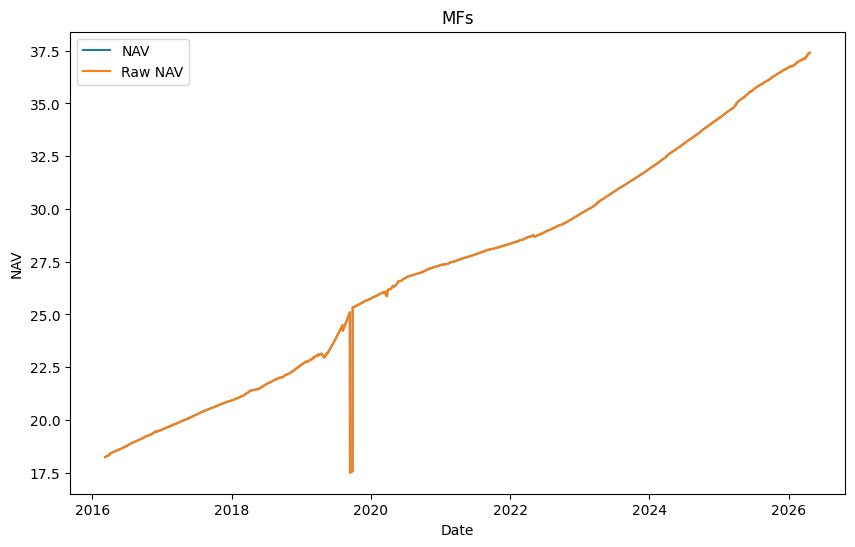

In [17]:
# Query
df = conn.execute(
    """
    SELECT sd_id, date, nav, raw_nav
    FROM nav
    WHERE sd_id = 138358
    ORDER BY date
    """
).pl()

# Plot with Matplotlib
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df['date'].to_list(), df['nav'].to_list(), label='NAV')
ax.plot(df['date'].to_list(), df['raw_nav'].to_list(), label='Raw NAV')
ax.set_title('MFs')
ax.set_xlabel('Date')
ax.set_ylabel('NAV')
ax.legend()
plt.show()

In [18]:
# Duplicate plan -> scheme
conn.execute(
    """
    SELECT sd_id, COUNT(DISTINCT scheme_id) count
    FROM nav
    LEFT JOIN plans_active USING (sd_id)
    WHERE sd_id in (SELECT sd_id from plans)
    GROUP BY sd_id HAVING COUNT(DISTINCT scheme) <> 1
    ORDER BY count DESC
    """
).pl().show(100)

sd_id,count
i32,i64


In [19]:
# Funds which get 0 randomly inbetween
conn.execute(
    """
    WITH first_positive AS (
        -- Identify the start of the valid series for each sd_id
        SELECT sd_id, min(date) AS start_date
        FROM nav
        WHERE nav > 0
        GROUP BY sd_id
    )
    SELECT
        a.sd_id,
        f.start_date AS first_non_zero_date,
        count(CASE WHEN a.nav <= 0 THEN 1 END) AS count_non_positive_after_start,
        string_agg(
            CASE WHEN a.nav <= 0 THEN a.date::VARCHAR END, 
            ', ' ORDER BY a.date
        ) AS non_positive_dates
    FROM nav a
    JOIN first_positive f 
        ON a.sd_id = f.sd_id
    WHERE a.date > f.start_date
    GROUP BY a.sd_id, f.start_date HAVING count_non_positive_after_start > 0;
    """
).pl().show(100)

sd_id,first_non_zero_date,count_non_positive_after_start,non_positive_dates
i32,date,i64,str


In [20]:
# High oscilations
conn.execute(
    """
    WITH lagged_data AS (
        SELECT 
            sd_id, date, nav,
            LAG(nav) OVER (PARTITION BY sd_id ORDER BY date ASC) as prev_nav
            , CASE 
                WHEN prev_nav = 0 THEN NULL 
                ELSE (nav / prev_nav) - 1 
            END AS simple_return
        FROM nav
    )
    SELECT 
        scheme, sd_id
        , max(simple_return) max_ret, arg_max(date, simple_return) max_date
        , min(simple_return) min_ret, arg_min(date, simple_return) min_date
        , sum(CASE WHEN simple_return > 0.36 THEN 1 END) high_osc
        , sum(CASE WHEN simple_return < -0.36 THEN 1 END) low_osc
        , QUANTILE_CONT(simple_return, 0.95) pct_95
        , QUANTILE_CONT(simple_return, 0.05) pct_05
    FROM lagged_data
    LEFT JOIN plans ap USING (sd_id) 
    GROUP BY scheme, sd_id HAVING max_ret > 0.36 OR min_ret < -0.36
    ORDER BY scheme;
    """
).pl()
# 133868 and 138358 are okay

scheme,sd_id,max_ret,max_date,min_ret,min_date,high_osc,low_osc,pct_95,pct_05
str,i32,f64,date,f64,date,"decimal[38,0]","decimal[38,0]",f64,f64
"""BANK OF INDIA CREDIT RISK FUND""",133868,1.21837,2022-03-31,-0.502194,2020-04-24,1,1,0.001071,-0.000398
"""PGIM India Ultra Short Duration Fund""",138358,0.441974,2019-09-27,-0.302921,2019-09-13,1,null,0.000797,0.000006


In [21]:
conn.execute(
    """
    SELECT *
    FROM plans
    WHERE TRUE
        -- AND sd_id in (120716)
        AND scheme ILIKE '%parag%'
    """
).pl()

fund_house_id,fund_house,scheme_id,scheme,sd_id,plan,scheme_type,category,subcategory,tax,aum,launch_date,start_date,latest_date,latest_nav,is_in_use,is_not_lockin,is_retail,is_etf,is_growth,is_direct
i32,str,i32,str,i32,str,str,str,str,"decimal[4,3]",f64,date,date,date,f64,bool,bool,bool,bool,bool,bool
64,"""PPFAS Mutual Fund""",7086,"""Parag Parikh Flexi Cap Fund""",122639,"""Parag Parikh Flexi Cap Fund - Direct Plan - Growth""","""Open Ended""","""equity""","""flexi cap""",0.125,8.4307e6,2013-05-13,2013-05-28,2026-04-21,92.1913,true,true,true,false,true,true
64,"""PPFAS Mutual Fund""",11186,"""Parag Parikh Liquid Fund""",143269,"""Parag Parikh Liquid Fund- Direct Plan- Growth""","""Open Ended""","""debt""","""liquid""",0.300,353870.47,2018-05-09,2018-05-14,2026-04-21,1532.2442,true,true,true,false,true,true
64,"""PPFAS Mutual Fund""",11988,"""Parag Parikh ELSS Tax Saver Fund""",147481,"""Parag Parikh ELSS Tax Saver Fund- Direct Growth""","""Open Ended""","""equity""","""elss""",0.125,387583.7,2019-07-04,2019-07-26,2026-04-21,32.6602,true,true,true,false,true,true
64,"""PPFAS Mutual Fund""",12246,"""Parag Parikh Conservative Hybrid Fund""",148958,"""Parag Parikh Conservative Hybrid Fund - Direct Plan - Growth""","""Open Ended""","""hybrid""","""conservative hybrid""",0.200,237457.25,2021-05-07,2021-05-28,2026-04-21,15.8262,true,true,true,false,true,true
64,"""PPFAS Mutual Fund""",13784,"""Parag Parikh Arbitrage Fund""",152109,"""Parag Parikh Arbitrage Fund - Direct Plan Growth""","""Open Ended""","""hybrid""","""arbitrage""",0.125,157038.42,2023-10-23,2023-11-03,2026-04-21,11.8587,true,true,true,false,true,true
64,"""PPFAS Mutual Fund""",13878,"""Parag Parikh Dynamic Asset Allocation Fund""",152468,"""Parag Parikh Dynamic Asset Allocation Fund - Direct Plan Growth""","""Open Ended""","""hybrid""","""dynamic asset allocation or balanced advantage""",0.200,209239.95,2024-02-20,2024-02-28,2026-04-21,11.7002,true,true,true,false,true,true
64,"""PPFAS Mutual Fund""",14405,"""Parag Parikh Large Cap Fund""",154155,"""Parag Parikh Large Cap Fund - Direct Plan - Growth""","""Open Ended""","""equity""","""large cap""",0.125,17230.06,2026-01-19,2026-02-06,2026-04-21,9.6876,true,true,true,false,true,true


In [22]:
conn.execute(
    """
    CREATE OR REPLACE TABLE returns_yearly AS
    WITH cagr AS (
        SELECT 
            sd_id,
            arg_min(nav, date) as first_nav,
            arg_max(nav, date) as last_nav,
            min(date) as start_date,
            max(date) as end_date,
            (pow(
                last_nav / first_nav, 
                1.0 / (date_diff('day', start_date, end_date) / 365.25)
            ) - 1) * 100 AS cagr
        FROM nav
        GROUP BY sd_id
    ),
    raw_yearly AS (
        SELECT 
            sd_id,
            concat('y_', year(date_trunc('year', date))) as year,
            arg_min(nav, date) as first_nav,
            arg_max(nav, date) as last_nav,
            min(date) as start_date,
            max(date) as end_date,
            ((last_nav / first_nav) - 1) * 100 AS simple_returns
        FROM nav
        LEFT JOIN plans USING (sd_id)
        GROUP BY sd_id, year HAVING month(start_date) < 5
    ),
    yearly AS (
        PIVOT raw_yearly
        ON year
        USING sum(simple_returns)
        GROUP BY sd_id
    )
    SELECT sd_id, scheme
        , cagr
        , y_2026, y_2025, y_2024
        , y_2023, y_2022, y_2021
        , y_2020, y_2019, y_2018
        , y_2017, y_2016, y_2015
    FROM cagr
    LEFT JOIN yearly USING (sd_id)
    LEFT JOIN plans USING (sd_id)
    """
)
conn.execute(
    """
    CREATE OR REPLACE TABLE returns_quarterly AS
    WITH raw_quarterly AS (
        SELECT 
            sd_id,
            concat('q_', year(date), '_', quarter(date)) as quarter,
            arg_min(nav, date) as first_nav,
            arg_max(nav, date) as last_nav,
            min(date) as start_date,
            max(date) as end_date,
            ((last_nav / first_nav) - 1) * 100 AS simple_returns
        FROM nav
        LEFT JOIN plans USING (sd_id)
        GROUP BY sd_id, quarter HAVING count(nav) > 30
    ),
    quarterly AS (
        PIVOT raw_quarterly
        ON quarter
        USING sum(simple_returns)
        GROUP BY sd_id
    )
    SELECT sd_id, scheme
        , q_2026_1
        , q_2025_4, q_2025_3, q_2025_2, q_2025_1
        , q_2024_4, q_2024_3, q_2024_2, q_2024_1
        , q_2023_4, q_2023_3, q_2023_2, q_2023_1
        , q_2022_4, q_2022_3, q_2022_2, q_2022_1
        , q_2021_4, q_2021_3, q_2021_2, q_2021_1
        , q_2020_4, q_2020_3, q_2020_2, q_2020_1
    FROM quarterly
    LEFT JOIN plans USING (sd_id)
    """
)

conn.execute(
    """
    CREATE OR REPLACE TABLE returns_monthly AS
    WITH raw_monthly AS (
        SELECT 
            sd_id,
            concat('m_', year(date), '_', lpad(month(date)::string, 2, '0')) as month,
            arg_min(nav, date) as first_nav,
            arg_max(nav, date) as last_nav,
            min(date) as start_date,
            max(date) as end_date,
            ((last_nav / first_nav) - 1) * 100 AS simple_returns
        FROM nav
        LEFT JOIN plans USING (sd_id)
        GROUP BY sd_id, month HAVING count(nav) > 10
    ),
    monthly AS (
        PIVOT raw_monthly
        ON month
        USING sum(simple_returns)
        GROUP BY sd_id
    )
    SELECT sd_id, scheme
        , m_2026_01, m_2026_02, m_2026_03
        , m_2025_12, m_2025_11, m_2025_10, m_2025_09, m_2025_08, m_2025_07, m_2025_06, m_2025_05, m_2025_04, m_2025_03, m_2025_02, m_2025_01
    FROM monthly
    LEFT JOIN plans USING (sd_id)
    """
)

In [92]:
conn.execute(
    """
    CREATE OR REPLACE TABLE config AS
    SELECT 
        0.06 AS risk_free_rate,
        252.0 AS trading_days,
        149039 AS benchmark_sd_id
    """
)

conn.execute(
    """
    CREATE OR REPLACE TABLE capm_yearly AS
    WITH config AS (
        SELECT 
            0.06 AS risk_free_rate,
            252.0 AS trading_days,
            120716 AS benchmark_sd_id
    ),
    daily_returns AS (
        SELECT 
            sd_id, 
            date, 
            year(date) AS yr,
            (nav / LAG(nav) OVER (PARTITION BY sd_id ORDER BY date ASC)) - 1 AS ret
        FROM nav
    ),
    benchmark_returns AS (
        SELECT date, ret AS bench_ret
        FROM daily_returns 
        WHERE sd_id = (SELECT benchmark_sd_id FROM config)
    ),
    aligned AS (
        SELECT 
            d.sd_id, 
            d.yr, 
            d.date, 
            d.ret AS fund_ret, 
            b.bench_ret
        FROM daily_returns d
        INNER JOIN benchmark_returns b ON d.date = b.date
        WHERE d.ret IS NOT NULL 
          AND b.bench_ret IS NOT NULL
          AND d.yr BETWEEN 2020 AND 2025
    ),
    period_returns AS (
        SELECT 
            sd_id, 
            year(date) AS yr,
            (arg_max(nav, date) / arg_min(nav, date)) - 1 AS per_ret
        FROM nav 
        WHERE year(date) BETWEEN 2020 AND 2025
        GROUP BY sd_id, year(date)
    ),
    bench_period_returns AS (
        SELECT yr, per_ret AS bench_per_ret
        FROM period_returns 
        WHERE sd_id = (SELECT benchmark_sd_id FROM config)
    ),
    stats AS (
        SELECT 
            a.sd_id, 
            a.yr,
            stddev_samp(a.fund_ret) * sqrt((SELECT trading_days FROM config)) AS ann_std_dev,
            covar_samp(a.fund_ret, a.bench_ret) / NULLIF(var_samp(a.bench_ret), 0) AS beta,
            stddev_samp(a.fund_ret - a.bench_ret) * sqrt((SELECT trading_days FROM config)) AS tracking_error
        FROM aligned a 
        GROUP BY a.sd_id, a.yr 
        HAVING count(a.date) > 200
    ),
    yearly_metrics AS (
        SELECT 
            p.sd_id, 
            p.yr,
            s.ann_std_dev AS std_dev,
            s.beta,
            -- Jensen's Alpha (Pure decimal)
            (p.per_ret - ((SELECT risk_free_rate FROM config) + s.beta * (b.bench_per_ret - (SELECT risk_free_rate FROM config)))) AS alpha,
            -- Information Ratio
            (p.per_ret - b.bench_per_ret) / NULLIF(s.tracking_error, 0) AS information_ratio
        FROM period_returns p
        INNER JOIN stats s ON p.sd_id = s.sd_id AND p.yr = s.yr
        INNER JOIN bench_period_returns b ON p.yr = b.yr
    )
    SELECT 
        m.sd_id,
        p.scheme,

        -- 2025 Metrics
        MAX(CASE WHEN yr = 2025 THEN alpha END) AS alpha_2025,
        MAX(CASE WHEN yr = 2025 THEN beta END) AS beta_2025,
        MAX(CASE WHEN yr = 2025 THEN information_ratio END) AS ir_2025,
        MAX(CASE WHEN yr = 2025 THEN std_dev END) AS sd_2025,

        -- 2024 Metrics
        MAX(CASE WHEN yr = 2024 THEN alpha END) AS alpha_2024,
        MAX(CASE WHEN yr = 2024 THEN beta END) AS beta_2024,
        MAX(CASE WHEN yr = 2024 THEN information_ratio END) AS ir_2024,
        MAX(CASE WHEN yr = 2024 THEN std_dev END) AS sd_2024,

        -- 2023 Metrics
        MAX(CASE WHEN yr = 2023 THEN alpha END) AS alpha_2023,
        MAX(CASE WHEN yr = 2023 THEN beta END) AS beta_2023,
        MAX(CASE WHEN yr = 2023 THEN information_ratio END) AS ir_2023,
        MAX(CASE WHEN yr = 2023 THEN std_dev END) AS sd_2023,
        
        -- 2022 Metrics
        MAX(CASE WHEN yr = 2022 THEN alpha END) AS alpha_2022,
        MAX(CASE WHEN yr = 2022 THEN beta END) AS beta_2022,
        MAX(CASE WHEN yr = 2022 THEN information_ratio END) AS ir_2022,
        MAX(CASE WHEN yr = 2022 THEN std_dev END) AS sd_2022,

        -- 2021 Metrics
        MAX(CASE WHEN yr = 2021 THEN alpha END) AS alpha_2021,
        MAX(CASE WHEN yr = 2021 THEN beta END) AS beta_2021,
        MAX(CASE WHEN yr = 2021 THEN information_ratio END) AS ir_2021,
        MAX(CASE WHEN yr = 2021 THEN std_dev END) AS sd_2021,

        -- 2020 Metrics
        MAX(CASE WHEN yr = 2020 THEN alpha END) AS alpha_2020,
        MAX(CASE WHEN yr = 2020 THEN beta END) AS beta_2020,
        MAX(CASE WHEN yr = 2020 THEN information_ratio END) AS ir_2020,
        MAX(CASE WHEN yr = 2020 THEN std_dev END) AS sd_2020

    FROM yearly_metrics m
    LEFT JOIN plans p ON m.sd_id = p.sd_id
    GROUP BY m.sd_id, p.scheme, p.plan
    ORDER BY alpha_2025 DESC NULLS LAST;
    """
).pl()

Count
i64
1718


In [93]:
conn.execute(
    """
    CREATE OR REPLACE MACRO tax_adj(val, tax_rate) AS 
        CASE 
            WHEN val > 0 THEN val * (1 - tax_rate)
            ELSE val 
        END;
    """
)

pl.Config(tbl_rows=100)


conn.execute(
    """
    SELECT sd_id, y.scheme, category, subcategory, tax
        , tax_adj(cagr, tax) cagr
        , tax_adj(y_2026, tax) y_2026
        , tax_adj(y_2025, tax) y_2025
        , tax_adj(y_2024, tax) y_2024
        , tax_adj(y_2023, tax) y_2023
        , tax_adj(y_2022, tax) y_2022
        , tax_adj(y_2021, tax) y_2021
        , tax_adj(y_2020, tax) y_2020
        , tax_adj(q_2026_1, tax) q_2026_1
        , tax_adj(q_2025_4, tax) q_2025_4
        , tax_adj(q_2025_3, tax) q_2025_3
        , tax_adj(q_2025_2, tax) q_2025_2
        , tax_adj(q_2025_1, tax) q_2025_1
        , tax_adj(m_2026_03, tax) m_2026_03
        , tax_adj(m_2026_02, tax) m_2026_02
        , tax_adj(m_2026_01, tax) m_2026_01
        , tax_adj(m_2025_12, tax) m_2025_12
        , tax_adj(m_2025_11, tax) m_2025_11
        , tax_adj(m_2025_10, tax) m_2025_10
        , tax_adj(m_2025_09, tax) m_2025_09

    FROM returns_yearly y
    LEFT JOIN returns_quarterly q USING (sd_id)
    LEFT JOIN returns_monthly m USING (sd_id)
    LEFT JOIN plans USING (sd_id)
    WHERE TRUE
        AND category not in ('other', 'elss')
        -- AND y_2026 + y_2025 + y_2024  > 36
        AND y.scheme ILIKE '%parag%liq%'
        
    ORDER BY y_2025 + y_2024 DESC
    """
).pl()

sd_id,scheme,category,subcategory,tax,cagr,y_2026,y_2025,y_2024,y_2023,y_2022,y_2021,y_2020,q_2026_1,q_2025_4,q_2025_3,q_2025_2,q_2025_1,m_2026_03,m_2026_02,m_2026_01,m_2025_12,m_2025_11,m_2025_10,m_2025_09
i32,str,str,str,"decimal[4,3]",f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
143269,"""Parag Parikh Liquid Fund""","""debt""","""liquid""",0.300,3.857891,1.343025,4.427465,4.921824,4.67485,3.218192,2.240671,2.606133,1.016782,0.999725,0.979139,1.120579,1.185614,0.335115,0.356941,0.295845,0.33859,0.323999,0.314463,0.317549


In [94]:

conn.execute(
    """
    CREATE OR REPLACE TABLE quant_yearly AS
    WITH daily_returns AS (
        SELECT 
            sd_id, 
            date, 
            year(date) AS yr,
            nav,
            (nav / LAG(nav) OVER (PARTITION BY sd_id ORDER BY date ASC)) - 1 AS ret,
            MAX(nav) OVER (PARTITION BY sd_id, year(date) ORDER BY date ASC) AS running_max
        FROM nav
    ),
    benchmark_returns AS (
        SELECT date, ret AS bench_ret
        FROM daily_returns 
        WHERE sd_id = (SELECT benchmark_sd_id FROM config)
    ),
    aligned AS (
        SELECT 
            d.sd_id, 
            d.yr, 
            d.date, 
            d.nav,
            d.running_max,
            d.ret AS fund_ret, 
            b.bench_ret
        FROM daily_returns d
        INNER JOIN benchmark_returns b USING (date)
        WHERE d.ret IS NOT NULL 
          AND b.bench_ret IS NOT NULL
          AND d.yr BETWEEN 2016 AND 2025
    ),
    period_returns AS (
        SELECT 
            sd_id, 
            year(date) AS yr,
            (arg_max(nav, date) / arg_min(nav, date)) - 1 AS per_ret
        FROM nav 
        WHERE year(date) BETWEEN 2016 AND 2025
        GROUP BY sd_id, year(date)
    ),
    bench_period_returns AS (
        SELECT yr, per_ret AS bench_per_ret
        FROM period_returns 
        WHERE sd_id = (SELECT benchmark_sd_id FROM config)
    ),
    stats AS (
        SELECT 
            a.sd_id, 
            a.yr,
            -- Absolute Risk
            stddev_samp(a.fund_ret) * sqrt((SELECT trading_days FROM config)) AS sd,
            sqrt(sum(pow(least(a.fund_ret, 0.0), 2)) / count(a.fund_ret)) * sqrt((SELECT trading_days FROM config)) AS dd,
            min((a.nav / a.running_max) - 1) AS md,
            arg_min(a.date, (a.nav / a.running_max) - 1) AS trough_date,
            arg_min(a.running_max, (a.nav / a.running_max) - 1) AS peak_nav,
            -- Systematic Risk
            covar_samp(a.fund_ret, a.bench_ret) / NULLIF(var_samp(a.bench_ret), 0) AS b,
            pow(corr(a.fund_ret, a.bench_ret), 2) AS r2,
            stddev_samp(a.fund_ret - a.bench_ret) * sqrt((SELECT trading_days FROM config)) AS te,
            -- Capture Compounding Components
            EXP(SUM(CASE WHEN a.bench_ret > 0 THEN LN(GREATEST(1 + a.fund_ret, 0.00001)) ELSE 0 END)) - 1 AS f_up,
            EXP(SUM(CASE WHEN a.bench_ret > 0 THEN LN(GREATEST(1 + a.bench_ret, 0.00001)) ELSE 0 END)) - 1 AS b_up,
            EXP(SUM(CASE WHEN a.bench_ret < 0 THEN LN(GREATEST(1 + a.fund_ret, 0.00001)) ELSE 0 END)) - 1 AS f_dn,
            EXP(SUM(CASE WHEN a.bench_ret < 0 THEN LN(GREATEST(1 + a.bench_ret, 0.00001)) ELSE 0 END)) - 1 AS b_dn
        FROM aligned a 
        GROUP BY a.sd_id, a.yr 
        HAVING count(a.date) > 200
    ),
    recovery AS (
        SELECT 
            s.sd_id, 
            s.yr,
            CASE 
                WHEN s.md >= 0 THEN 0 
                ELSE date_diff('day', s.trough_date, MIN(n.date))
            END AS md_rec
        FROM stats s
        LEFT JOIN nav n 
            ON s.sd_id = n.sd_id 
           AND n.date > s.trough_date 
           AND n.nav >= s.peak_nav
        GROUP BY s.sd_id, s.yr, s.md, s.trough_date
    ),
    yearly_metrics AS (
        SELECT 
            p.sd_id, 
            p.yr,
            s.sd * 100 sd,
            s.dd * 100 dd,
            s.md * 100 md,
            r.md_rec,
            s.b,
            s.r2,
            -- Risk-Adjusted Returns
            (p.per_ret - c.risk_free_rate) / NULLIF(s.sd, 0) AS sp,
            (p.per_ret - c.risk_free_rate) / NULLIF(s.dd, 0) AS so,
            p.per_ret / NULLIF(ABS(s.md), 0) AS cl,
            (p.per_ret - c.risk_free_rate) / NULLIF(s.b, 0) AS t,
            -- Active Management
            (p.per_ret - (c.risk_free_rate + s.b * (bp.bench_per_ret - c.risk_free_rate))) AS a,
            (p.per_ret - bp.bench_per_ret) / NULLIF(s.te, 0) AS ir,
            s.f_up / NULLIF(s.b_up, 0) AS ucr,
            s.f_dn / NULLIF(s.b_dn, 0) AS dcr
        FROM period_returns p
        INNER JOIN stats s ON p.sd_id = s.sd_id AND p.yr = s.yr
        LEFT JOIN recovery r ON s.sd_id = r.sd_id AND s.yr = r.yr
        INNER JOIN bench_period_returns bp ON p.yr = bp.yr
        CROSS JOIN config c
    )
    SELECT 
        m.sd_id,
        p.scheme,

        -- 2025
        MAX(CASE WHEN yr = 2025 THEN sd END) AS sd_2025,
        MAX(CASE WHEN yr = 2025 THEN dd END) AS dd_2025,
        MAX(CASE WHEN yr = 2025 THEN md END) AS md_2025,
        MAX(CASE WHEN yr = 2025 THEN md_rec END) AS md_rec_2025,
        MAX(CASE WHEN yr = 2025 THEN b END) AS b_2025,
        MAX(CASE WHEN yr = 2025 THEN r2 END) AS r2_2025,
        MAX(CASE WHEN yr = 2025 THEN sp END) AS sp_2025,
        MAX(CASE WHEN yr = 2025 THEN so END) AS so_2025,
        MAX(CASE WHEN yr = 2025 THEN cl END) AS cl_2025,
        MAX(CASE WHEN yr = 2025 THEN t END) AS t_2025,
        MAX(CASE WHEN yr = 2025 THEN a END) AS a_2025,
        MAX(CASE WHEN yr = 2025 THEN ir END) AS ir_2025,
        MAX(CASE WHEN yr = 2025 THEN ucr END) AS ucr_2025,
        MAX(CASE WHEN yr = 2025 THEN dcr END) AS dcr_2025,
    
        -- 2024
        MAX(CASE WHEN yr = 2024 THEN sd END) AS sd_2024,
        MAX(CASE WHEN yr = 2024 THEN dd END) AS dd_2024,
        MAX(CASE WHEN yr = 2024 THEN md END) AS md_2024,
        MAX(CASE WHEN yr = 2024 THEN md_rec END) AS md_rec_2024,
        MAX(CASE WHEN yr = 2024 THEN b END) AS b_2024,
        MAX(CASE WHEN yr = 2024 THEN r2 END) AS r2_2024,
        MAX(CASE WHEN yr = 2024 THEN sp END) AS sp_2024,
        MAX(CASE WHEN yr = 2024 THEN so END) AS so_2024,
        MAX(CASE WHEN yr = 2024 THEN cl END) AS cl_2024,
        MAX(CASE WHEN yr = 2024 THEN t END) AS t_2024,
        MAX(CASE WHEN yr = 2024 THEN a END) AS a_2024,
        MAX(CASE WHEN yr = 2024 THEN ir END) AS ir_2024,
        MAX(CASE WHEN yr = 2024 THEN ucr END) AS ucr_2024,
        MAX(CASE WHEN yr = 2024 THEN dcr END) AS dcr_2024,
    
        -- 2023
        MAX(CASE WHEN yr = 2023 THEN sd END) AS sd_2023,
        MAX(CASE WHEN yr = 2023 THEN dd END) AS dd_2023,
        MAX(CASE WHEN yr = 2023 THEN md END) AS md_2023,
        MAX(CASE WHEN yr = 2023 THEN md_rec END) AS md_rec_2023,
        MAX(CASE WHEN yr = 2023 THEN b END) AS b_2023,
        MAX(CASE WHEN yr = 2023 THEN r2 END) AS r2_2023,
        MAX(CASE WHEN yr = 2023 THEN sp END) AS sp_2023,
        MAX(CASE WHEN yr = 2023 THEN so END) AS so_2023,
        MAX(CASE WHEN yr = 2023 THEN cl END) AS cl_2023,
        MAX(CASE WHEN yr = 2023 THEN t END) AS t_2023,
        MAX(CASE WHEN yr = 2023 THEN a END) AS a_2023,
        MAX(CASE WHEN yr = 2023 THEN ir END) AS ir_2023,
        MAX(CASE WHEN yr = 2023 THEN ucr END) AS ucr_2023,
        MAX(CASE WHEN yr = 2023 THEN dcr END) AS dcr_2023,
    
        -- 2022
        MAX(CASE WHEN yr = 2022 THEN sd END) AS sd_2022,
        MAX(CASE WHEN yr = 2022 THEN dd END) AS dd_2022,
        MAX(CASE WHEN yr = 2022 THEN md END) AS md_2022,
        MAX(CASE WHEN yr = 2022 THEN md_rec END) AS md_rec_2022,
        MAX(CASE WHEN yr = 2022 THEN b END) AS b_2022,
        MAX(CASE WHEN yr = 2022 THEN r2 END) AS r2_2022,
        MAX(CASE WHEN yr = 2022 THEN sp END) AS sp_2022,
        MAX(CASE WHEN yr = 2022 THEN so END) AS so_2022,
        MAX(CASE WHEN yr = 2022 THEN cl END) AS cl_2022,
        MAX(CASE WHEN yr = 2022 THEN t END) AS t_2022,
        MAX(CASE WHEN yr = 2022 THEN a END) AS a_2022,
        MAX(CASE WHEN yr = 2022 THEN ir END) AS ir_2022,
        MAX(CASE WHEN yr = 2022 THEN ucr END) AS ucr_2022,
        MAX(CASE WHEN yr = 2022 THEN dcr END) AS dcr_2022,
    
        -- 2021
        MAX(CASE WHEN yr = 2021 THEN sd END) AS sd_2021,
        MAX(CASE WHEN yr = 2021 THEN dd END) AS dd_2021,
        MAX(CASE WHEN yr = 2021 THEN md END) AS md_2021,
        MAX(CASE WHEN yr = 2021 THEN md_rec END) AS md_rec_2021,
        MAX(CASE WHEN yr = 2021 THEN b END) AS b_2021,
        MAX(CASE WHEN yr = 2021 THEN r2 END) AS r2_2021,
        MAX(CASE WHEN yr = 2021 THEN sp END) AS sp_2021,
        MAX(CASE WHEN yr = 2021 THEN so END) AS so_2021,
        MAX(CASE WHEN yr = 2021 THEN cl END) AS cl_2021,
        MAX(CASE WHEN yr = 2021 THEN t END) AS t_2021,
        MAX(CASE WHEN yr = 2021 THEN a END) AS a_2021,
        MAX(CASE WHEN yr = 2021 THEN ir END) AS ir_2021,
        MAX(CASE WHEN yr = 2021 THEN ucr END) AS ucr_2021,
        MAX(CASE WHEN yr = 2021 THEN dcr END) AS dcr_2021,
    
        -- 2020
        MAX(CASE WHEN yr = 2020 THEN sd END) AS sd_2020,
        MAX(CASE WHEN yr = 2020 THEN dd END) AS dd_2020,
        MAX(CASE WHEN yr = 2020 THEN md END) AS md_2020,
        MAX(CASE WHEN yr = 2020 THEN md_rec END) AS md_rec_2020,
        MAX(CASE WHEN yr = 2020 THEN b END) AS b_2020,
        MAX(CASE WHEN yr = 2020 THEN r2 END) AS r2_2020,
        MAX(CASE WHEN yr = 2020 THEN sp END) AS sp_2020,
        MAX(CASE WHEN yr = 2020 THEN so END) AS so_2020,
        MAX(CASE WHEN yr = 2020 THEN cl END) AS cl_2020,
        MAX(CASE WHEN yr = 2020 THEN t END) AS t_2020,
        MAX(CASE WHEN yr = 2020 THEN a END) AS a_2020,
        MAX(CASE WHEN yr = 2020 THEN ir END) AS ir_2020,
        MAX(CASE WHEN yr = 2020 THEN ucr END) AS ucr_2020,
        MAX(CASE WHEN yr = 2020 THEN dcr END) AS dcr_2020,

        MAX(CASE WHEN yr = 2019 THEN md END) AS md_2019,
        MAX(CASE WHEN yr = 2019 THEN md_rec END) AS md_rec_2019,
        MAX(CASE WHEN yr = 2018 THEN md END) AS md_2018,
        MAX(CASE WHEN yr = 2018 THEN md_rec END) AS md_rec_2018
    
    FROM yearly_metrics m
    LEFT JOIN plans p ON m.sd_id = p.sd_id
    GROUP BY m.sd_id, p.scheme, p.plan;
    """
).pl()

Count
i64
1718


In [95]:
# Debt funds
conn.execute(
    f"""
    SELECT y.sd_id, y.scheme, subcategory, aum

        , y_2025
        , y_2024
        , y_2023
        , y_2022
        , y_2021
        , y_2020

        , y.md_2025
        , y.md_2024
        , y.md_2023
        , y.md_2022
        , y.md_2021
        , y.md_2020

        , y.a_2025, y.a_2024, y.a_2023, y.a_2022, y.a_2021, y.a_2020

        , y.so_2025
        , y.so_2024
        , y.so_2023
        , y.so_2022
        , y.so_2021
        , y.so_2020

    FROM quant_yearly y
    LEFT JOIN returns_yearly r USING (sd_id)
    LEFT JOIN plans p USING (sd_id)
    WHERE TRUE
        -- AND y.sd_id IN {inc_arb_ids}
        AND category = 'debt' AND subcategory = 'liquid'

        AND r.y_2025 > 6.6 AND r.y_2024 > 7.4 AND r.y_2023 > 6
        AND y.md_2025 > -1 AND y.md_2024 > -1 AND y.md_2023 > -1
    ORDER BY r.y_2025 + r.y_2024 + r.y_2023 DESC
    """
).pl()

sd_id,scheme,subcategory,aum,y_2025,y_2024,y_2023,y_2022,y_2021,y_2020,md_2025,md_2024,md_2023,md_2022,md_2021,md_2020,a_2025,a_2024,a_2023,a_2022,a_2021,a_2020,so_2025,so_2024,so_2023,so_2022,so_2021,so_2020
i32,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
119568,"""Aditya Birla Sun Life Liquid Fund""","""liquid""",4.0437e6,6.627703,7.457128,7.168805,4.936952,3.368897,4.379449,0.0,0.0,-0.03492,-0.047231,null,null,0.006232,0.014561,0.011453,-0.010613,null,null,null,null,37.846932,-29.885809,null,null
140196,"""Edelweiss Liquid Fund""","""liquid""",950095.23,6.611332,7.504222,7.090366,4.896974,3.479046,4.371589,-0.000339,0.0,-0.015851,-0.062291,null,null,0.006067,0.015029,0.010696,-0.011011,null,null,1787.53798,null,68.248915,-23.514717,null,null
139538,"""Mahindra Manulife Liquid Fund""","""liquid""",88658.34,6.600559,7.445737,7.148827,4.974767,3.404518,4.384007,0.0,0.0,-0.008737,-0.026835,null,null,0.005965,0.014445,0.011338,-0.010236,null,null,null,null,146.197286,-41.460936,null,null
120389,"""Axis Liquid Fund""","""liquid""",3.1288e6,6.632423,7.441207,7.109541,4.941106,3.34694,4.324204,0.0,0.0,-0.017525,-0.030561,null,null,0.006283,0.014397,0.010944,-0.010573,null,null,null,null,68.035272,-44.061392,null,null
138299,"""PGIM India Liquid Fund""","""liquid""",45981.25,6.60371,7.42876,7.143533,4.915473,3.371645,4.346656,-0.00077,0.0,-0.031093,-0.034096,null,null,0.005993,0.014275,0.011216,-0.010832,null,null,777.841877,null,41.292389,-39.257054,null,null
118305,"""Canara Robeco Liquid Fund""","""liquid""",591446.65,6.621883,7.409524,7.101931,4.892688,3.251519,3.690243,-0.002342,0.0,-0.020658,-0.005368,null,null,0.006171,0.014086,0.01089,-0.011065,null,null,263.369113,null,60.031827,-204.239659,null,null
149664,"""Sundaram Liquid Fund (Formerly Known as Principal Cash Management Fund)""","""liquid""",614966.56,6.605015,7.441668,7.079294,4.950659,null,null,0.0,0.0,-0.017882,-0.023487,null,null,0.005995,0.014404,0.010627,-0.01048,null,null,null,null,59.3911,-45.909725,null,null
118701,"""Nippon India Liquid Fund""","""liquid""",2.5351e6,6.600795,7.429579,7.089414,4.910946,3.363355,4.348734,-0.000832,0.0,-0.029842,-0.053799,null,null,0.005969,0.014282,0.010694,-0.010871,null,null,716.595204,null,41.403045,-25.963716,null,null
119861,"""Tata Liquid Fund""","""liquid""",2.0031e6,6.61981,7.413886,7.071966,4.874827,3.336745,4.409499,-0.002868,0.0,-0.021306,-0.050009,null,null,0.006149,0.014127,0.010582,-0.011235,null,null,214.363548,null,57.087675,-29.339546,null,null


In [96]:
conn.execute(
    f"""
    WITH bench AS (
        SELECT *
        FROM quant_yearly
        WHERE sd_id = 149039
    )
    SELECT y.sd_id, y.scheme

        , r.y_2025
        , r.y_2024
        , r.y_2023
        , r.y_2022
        , r.y_2021
        , r.y_2020

        , b.md_2025 - y.md_2025 d_md_2025
        , b.md_2024 - y.md_2024 d_md_2024
        , b.md_2023 - y.md_2023 d_md_2023
        , b.md_2022 - y.md_2022 d_md_2022
        , b.md_2021 - y.md_2021 d_md_2021
        , b.md_2020 - y.md_2020 d_md_2020

        , y.a_2025, y.a_2024, y.a_2023, y.a_2022, y.a_2021, y.a_2020

        , y.so_2025 - b.so_2025 d_so_2025
        , y.so_2024 - b.so_2024 d_so_2024
        , y.so_2023 - b.so_2023 d_so_2023
        , y.so_2022 - b.so_2022 d_so_2022
        , y.so_2021 - b.so_2021 d_so_2021
        , y.so_2020 - b.so_2020 d_so_2020

    FROM quant_yearly y
    LEFT JOIN returns_yearly r USING (sd_id)
    LEFT JOIN plans p USING (sd_id)
    CROSS JOIN bench b
    LEFT JOIN returns_yearly ry ON b.sd_id = ry.sd_id
    WHERE TRUE
        -- AND y.md_2025 > -2 AND y.md_2024 > -1 AND y.md_2023 > -1
        AND d_md_2025 < 1 AND d_md_2024 < 1 AND d_md_2023 < 1
        AND y.a_2024 > 0.05 AND y.a_2023 > 0.05
        AND tax_adj(r.y_2025, tax) > 10 AND tax_adj(r.y_2024, tax) > 10 AND tax_adj(r.y_2023, tax) > 10
    ORDER BY y.a_2023 + y.a_2022 DESC
    --ORDER BY y_2025 + y_2024 DESC
    """
).pl()

sd_id,scheme,y_2025,y_2024,y_2023,y_2022,y_2021,y_2020,d_md_2025,d_md_2024,d_md_2023,d_md_2022,d_md_2021,d_md_2020,a_2025,a_2024,a_2023,a_2022,a_2021,a_2020,d_so_2025,d_so_2024,d_so_2023,d_so_2022,d_so_2021,d_so_2020
i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
145897,"""ICICI Prudential India Opportunities Fund""",13.520198,22.696477,36.700649,19.397993,50.553191,8.542247,-0.638171,-1.512639,-1.185195,-3.067894,null,null,0.028445,0.139304,0.201765,0.150188,null,null,0.313301,1.799813,3.428707,1.423221,null,null
129312,"""ICICI Prudential Dividend Yield Equity Fund""",12.694633,22.4476,39.936809,9.88819,47.966632,14.930765,0.01214,0.030019,-2.745882,-1.960746,null,null,0.019586,0.129222,0.228198,0.056629,null,null,0.202515,1.204414,4.204595,0.541196,null,null
118950,"""HDFC Focused Fund""",11.676803,25.399515,30.781242,18.178099,41.101271,4.729673,-0.873073,-3.891163,-2.205962,-4.426565,null,null,0.014283,0.165695,0.135961,0.140072,null,null,0.17105,2.036286,2.343866,1.308137,null,null
118955,"""HDFC Flexi Cap Fund""",11.77568,24.248053,30.669438,17.287922,36.170054,6.613401,-0.175538,-3.526285,-1.045232,-3.058157,null,null,0.012837,0.151852,0.12228,0.13229,null,null,0.152446,1.75011,1.869862,1.160872,null,null
120323,"""ICICI Prudential Value Fund (erstwhile Value Discovery Fund)""",13.912394,20.528522,31.152186,14.62422,37.915895,23.026878,-0.649175,-1.637846,-2.173775,-2.683124,null,null,0.034644,0.115401,0.141529,0.102064,null,null,0.495741,1.412313,2.734646,1.050424,null,null
120334,"""ICICI Prudential Multi-Asset Fund""",19.001417,16.900717,24.174202,16.628712,35.02795,10.415283,-5.106036,-5.289705,-4.613228,-7.284956,null,null,0.103496,0.090286,0.107501,0.117094,null,null,2.500342,1.680081,3.115966,1.724223,null,null
148651,"""ICICI Prudential Business Cycle Fund""",16.177097,21.077162,33.541234,10.5547,28.171828,null,-0.502408,-1.956876,-0.833361,-3.979255,null,null,0.054217,0.119846,0.155316,0.062712,null,null,0.704281,1.306053,2.665559,0.63231,null,null
120596,"""ICICI Prudential Large & Mid Cap Fund""",14.601332,21.079412,30.009879,11.112647,41.602144,12.15074,-0.659394,-0.095512,-0.908193,-2.030754,null,null,0.038226,0.11928,0.126065,0.070554,null,null,0.38903,1.217961,2.002865,0.616821,null,null
120251,"""ICICI Prudential Equity & Debt Fund""",13.431059,17.92023,28.084306,11.120936,41.914829,9.359051,-2.710415,-2.50609,-3.474438,-5.068089,null,null,0.036678,0.092481,0.129143,0.064546,null,null,0.595492,1.190585,3.041548,0.799799,null,null


In [108]:
conn.execute(
    f"""
    SELECT *
    FROM plans
    WHERE 
    scheme ILIKE '%nifty%100%index%'
    -- sd_id = 151762
    ORDER BY aum DESC
    """
).pl()
# NN50
# 120684, 143341, 150477
# 150899, 148745, 153789, 149447
# N50 EQ
# 150639, 151762,149107
# 153150
# N100 EQ
# 153146, 149870

fund_house_id,fund_house,scheme_id,scheme,sd_id,plan,scheme_type,category,subcategory,tax,aum,launch_date,start_date,latest_date,latest_nav,is_in_use,is_not_lockin,is_retail,is_etf,is_growth,is_direct
i32,str,i32,str,i32,str,str,str,str,"decimal[4,3]",f64,date,date,date,f64,bool,bool,bool,bool,bool,bool
48,"""Bandhan Mutual Fund""",13155,"""BANDHAN Nifty100 Low Volatility 30 Index Fund""",150636,"""BANDHAN NIFTY100 LOW VOLATILITY 30 INDEX FUND - GROWTH - DIRECT PLAN""","""Open Ended""","""other""","""index funds""",0.125,160612.11,2022-09-15,2022-10-07,2026-04-13,15.2078,true,true,true,false,true,true
53,"""Axis Mutual Fund""",12029,"""Axis Nifty 100 Index Fund""",147666,"""Axis Nifty 100 Index Fund - Direct Plan - Growth Option""","""Open Ended""","""other""","""index funds""",0.125,139584.58,2019-09-27,2019-10-23,2026-04-13,21.933,true,true,true,false,true,true
9,"""HDFC Mutual Fund""",12721,"""HDFC NIFTY 100 Equal Weight Index Fund""",149870,"""HDFC Nifty 100 Equal Weight Index Fund - Direct Plan - Growth Option""","""Open Ended""","""other""","""index funds""",0.125,28011.5,2022-02-11,2022-02-23,2026-04-13,16.4922,true,true,true,false,true,true
9,"""HDFC Mutual Fund""",12720,"""HDFC NIFTY 100 Index Fund""",149868,"""HDFC NIFTY 100 Index Fund - Direct Plan - Growth Option""","""Open Ended""","""other""","""index funds""",0.125,22189.95,2022-02-11,2022-02-23,2026-04-13,14.609,true,true,true,false,true,true
9,"""HDFC Mutual Fund""",13946,"""HDFC NIFTY100 Low Volatility 30 Index Fund""",152713,"""HDFC NIFTY100 Low Volatility 30 Index Fund - Direct Plan""","""Open Ended""","""other""","""index funds""",0.125,15674.72,2024-06-21,2024-07-10,2026-04-13,10.0116,true,true,true,false,false,true
47,"""Edelweiss Mutual Fund""",12318,"""Edelweiss Nifty 100 Quality 30 Index Fund""",149254,"""Edelweiss Nifty 100 Quality 30 Index Fund Direct Plan Growth""","""Open Ended""","""other""","""index funds""",0.125,12604.46,2021-10-07,2021-10-07,2026-04-13,14.0627,true,true,true,false,true,true
48,"""Bandhan Mutual Fund""",12712,"""BANDHAN NIFTY 100 INDEX FUND""",149832,"""BANDHAN NIFTY 100 INDEX FUND - DIRECT PLAN - GROWTH""","""Open Ended""","""other""","""index funds""",0.125,11032.55,2022-02-07,2022-02-25,2026-04-13,14.6874,true,true,true,false,true,true
17,"""Kotak Mahindra Mutual Fund""",13931,"""Kotak NIFTY 100 Low Volatility 30 Index Fund""",152663,"""Kotak NIFTY 100 Low Volatility 30 Index Fund - Direct plan - Growth option""","""Open Ended""","""other""","""index funds""",0.125,9289.03,2024-05-22,2024-06-12,2026-04-13,10.4285,true,true,true,false,true,true
9,"""HDFC Mutual Fund""",14114,"""HDFC Nifty100 Quality 30 Index Fund""",153264,"""HDFC Nifty100 Quality 30 Index Fund - Direct Plan""","""Open Ended""","""other""","""index funds""",0.125,7453.43,2025-01-31,2025-02-20,2026-04-13,10.3559,true,true,true,false,false,true


In [113]:
indexes = (
    # -- N50
    # 120716, 119063, 120620,
    # -- Cheap N50
    149039, # 149250, 112351,
    # -- NN50
    120684, # 143341, 150477,
    # # -- Cheap NN50
    # 150899, 148745, 153789, 149447,
    # # -- N50 EQ
    # 150639, 151762,149107,
    # # -- Cheap N50 EQ
    # 153150,
    # N100
    149868,
    # -- N100 EQ
    149870,# 153146
    # Mid150
    # 151724, 153089, 149389,
    # Cheap Mid150
    # 153581
)

# Arbitrage funds
conn.execute(
    f"""
    SELECT y.sd_id, y.scheme, aum

        , y_2025
        , y_2024
        , y_2023
        , y_2022
        , y_2021
        , y_2020

        , y.md_2025
        , y.md_2024
        , y.md_2023
        , y.md_2022
        , y.md_2021
        , y.md_2020

        , y.a_2025, y.a_2024, y.a_2023, y.a_2022, y.a_2021, y.a_2020

        , y.so_2025
        , y.so_2024
        , y.so_2023
        , y.so_2022
        , y.so_2021
        , y.so_2020

    FROM quant_yearly y
    LEFT JOIN returns_yearly r USING (sd_id, scheme)
    LEFT JOIN plans p USING (sd_id)
    WHERE TRUE
        -- AND y.sd_id IN {inc_arb_ids}
        AND sd_id in {str(indexes)}
    
        --AND y.md_2025 > -1 AND y.md_2024 > -1 AND y.md_2023 > -1 AND y.md_2022 > -1 AND y.md_2021 > -1 AND y.md_2020 > -1
    -- ORDER BY r.y_2025 + r.y_2024 + r.y_2023 + r.y_2022 + r.y_2021 + r.y_2020 DESC
    ORDER BY aum DESC
    """
).pl()

sd_id,scheme,aum,y_2025,y_2024,y_2023,y_2022,y_2021,y_2020,md_2025,md_2024,md_2023,md_2022,md_2021,md_2020,a_2025,a_2024,a_2023,a_2022,a_2021,a_2020,so_2025,so_2024,so_2023,so_2022,so_2021,so_2020
i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
120684,"""ICICI Prudential Nifty Next 50 Index Fund""",582335.6,2.075481,27.370334,26.625798,-0.269878,29.078574,14.78679,-17.441522,-14.174088,-12.741533,-19.21349,null,null,-0.100966,0.168966,0.074764,-0.041134,null,null,-0.306283,1.410474,2.282904,-0.415314,null,null
149039,"""Navi Nifty 50 Index Fund""",366889.35,11.272834,9.750261,20.479431,3.806375,null,null,-8.505778,-10.816147,-7.010437,-15.93817,null,null,0.0,0.0,0.0,0.0,null,null,0.688651,0.369168,2.287892,-0.176956,null,null
149870,"""HDFC NIFTY 100 Equal Weight Index Fund""",28011.5,8.492971,16.472306,29.493035,4.257194,null,null,-12.429256,-13.997911,-9.623571,-16.115274,null,null,-0.032449,0.065368,0.105554,0.003417,null,null,0.24627,0.864535,3.296451,-0.134232,null,null
149868,"""HDFC NIFTY 100 Index Fund""",22189.95,9.425621,12.309837,20.30365,6.312755,null,null,-10.021248,-11.37893,-8.573086,-14.913927,null,null,-0.019972,0.024457,-0.000113,0.024909,null,null,0.417232,0.584627,2.205359,0.025657,null,null


In [338]:
df = conn.execute("SELECT * FROM returns_periodic").pl()

# Identify numeric columns to bin
numeric_cols = [
    # 'a_2025', 'a_2024', 'a_2023', 'a_2022', 'a_2021',
    'q_2026_1', 'q_2025_4', 'q_2025_3', 'q_2025_2', 'q_2025_1',
]

# Percentiles and corresponding bin labels
percentiles = [0.95, 0.75, 0.50, 0.25]
bin_labels = [5, 25, 50, 75, 100]

# Dictionary to store thresholds for each column
thresholds_dict = {}

# Compute thresholds column by column
for col in numeric_cols:
    thresholds = [df.select(pl.col(col).quantile(p)).item() for p in percentiles]
    thresholds_dict[col] = thresholds

# Function to assign bins based on thresholds
def assign_bins(col_name):
    expr = pl.when(pl.col(col_name) >= thresholds_dict[col_name][0]).then(bin_labels[0])
    for t, b in zip(thresholds_dict[col_name][1:], bin_labels[1:]):
        expr = expr.when(pl.col(col_name) >= t).then(b)
    expr = expr.otherwise(bin_labels[-1])
    return expr.alias(f"{col_name}_bin")

# Apply binning for all numeric columns
df_binned = df.select([
    pl.col("sd_id"),
    pl.col("plan"),
    *[assign_bins(c) for c in numeric_cols]
])

# List of binned columns
binned_cols = [c for c in df_binned.columns if c.endswith("_bin")]


# Create counts for each bin
df_bin_counts = df_binned.select([
    pl.col("sd_id"),
    pl.col("plan"),
    *[
        # sum across columns where value equals the bin
        pl.sum_horizontal([(pl.col(col) == b).cast(pl.Int32) for col in binned_cols ]).alias(str(b))
        for b in bin_labels
    ]
])
conn.execute(
    """
    SELECT *
    FROM df_bin_counts
    WHERE TRUE
    AND "100" < 1 and "50" <= 1
    --AND sd_id = 122639
    ORDER BY "5" DESC 
    """
).pl()

sd_id,plan,5,25,50,75,100
i32,str,i32,i32,i32,i32,i32
152476,"""Zerodha Gold ETF""",4,0,0,1,0
149758,"""Nippon India Silver ETF""",4,0,0,1,0
149779,"""Aditya Birla Sun Life Silver ETF""",4,0,0,1,0
113076,"""ICICI Prudential Gold ETF""",4,0,0,1,0
113434,"""Axis Gold ETF""",4,0,0,1,0
…,…,…,…,…,…,…
118780,"""Nippon India Credit Risk Fund - Direct Plan - Growth Plan""",0,3,0,2,0
152869,"""Kotak CRISIL -IBX AAA Financial Services Index Sep-2027 Fund-DIRECT PLAN-GROWTH Option""",0,2,1,2,0
102134,"""ICICI Prudential Multi Sector Passive FOF - IDCW""",0,1,1,3,0


In [335]:

# Load data
df = conn.execute("SELECT * FROM sortino_pt").pl()

# Identify numeric columns
numeric_cols = [c for c, dtype in zip(df.columns, df.dtypes) if dtype in [pl.Float64, pl.Float32]]

# Percentiles and corresponding bin labels
percentiles = [0.95, 0.75, 0.50, 0.25]
bin_labels = [5, 25, 50, 75, 100]

# Pre-fill nulls in numeric columns with a very small value
df = df.with_columns([pl.col(c).fill_null(float("-inf")).alias(c) for c in numeric_cols])

# Compute thresholds
thresholds_dict = {}
for col in numeric_cols:
    thresholds = [df.select(pl.col(col).quantile(p)).item() for p in percentiles]
    thresholds_dict[col] = thresholds

# Function to assign bins
def assign_bins(col_name):
    expr = pl.when(pl.col(col_name) >= thresholds_dict[col_name][0]).then(bin_labels[0])
    for t, b in zip(thresholds_dict[col_name][1:], bin_labels[1:]):
        expr = expr.when(pl.col(col_name) >= t).then(b)
    expr = expr.otherwise(bin_labels[-1])
    return expr.alias(f"{col_name}_bin")

# Create binned columns
df_binned = df.select([
    pl.col("sd_id"),
    pl.col("plan"),
    *[assign_bins(c) for c in numeric_cols]
])

# List of binned columns
binned_cols = [c for c in df_binned.columns if c.endswith("_bin")]

# Count number of columns in each bin
df_bin_counts = df_binned.select([
    pl.col("sd_id"),
    pl.col("plan"),
    *[
        pl.sum_horizontal([(pl.col(col) == b).cast(pl.Int32) for col in binned_cols]).alias(str(b))
        for b in bin_labels
    ]
])

conn.execute(
    """
    SELECT b.*
    FROM df_bin_counts b
    LEFT JOIN plans USING (sd_id)
    WHERE TRUE
     AND "100" < 1
     AND "75" < 1
     --and "50" <= 1
    -- AND sd_id = 122639
    ORDER BY "5" + "25" DESC 
    """
).pl()

sd_id,plan,5,25,50,75,100
i32,str,i32,i32,i32,i32,i32
134387,"""Aditya Birla Sun Life Credit Risk Fund - Direct Plan - Growth""",1,5,0,0,0
145724,"""Tata Arbitrage Fund-Direct Plan-Growth""",0,5,1,0,0
130314,"""Axis Credit Risk Fund - Direct Plan - Growth""",0,5,1,0,0
140347,"""Edelweiss Equity Savings Fund - Direct Plan - Growth Option""",0,5,1,0,0
136465,"""HDFC Retirement Savings Fund - Hybrid-Debt Plan - Growth Option - Direct Plan""",0,4,2,0,0
…,…,…,…,…,…,…
138376,"""PGIM India Equity Savings Fund - Direct Plan - Growth""",0,1,5,0,0
146940,"""Aditya Birla Sun Life Retirement Fund-The 50s Plan-Direct Plan-Growth""",1,0,5,0,0
147496,"""Baroda BNP Paribas Equity Savings Fund - Direct Plan - Growth""",0,1,5,0,0


In [137]:
conn.execute(
    """
    CREATE OR REPLACE TABLE returns_periodic_benchmark AS
    WITH benchmark AS (
        SELECT * FROM returns_periodic 
        WHERE sd_id = 120716
    )
    SELECT 
        f.sd_id, 
        f.plan,
        f.cagr - b.cagr AS cagr,
        
        -- Yearly Active
        f.a_2026 - b.a_2026 AS a_2026,
        f.a_2025 - b.a_2025 AS a_2025,
        f.a_2024 - b.a_2024 AS a_2024,
        f.a_2023 - b.a_2023 AS a_2023,
        f.a_2022 - b.a_2022 AS a_2022,
        f.a_2021 - b.a_2021 AS a_2021,
        f.a_2020 - b.a_2020 AS a_2020,
        f.a_2019 - b.a_2019 AS a_2019,
        f.a_2018 - b.a_2018 AS a_2018,
        f.a_2017 - b.a_2017 AS a_2017,
        f.a_2016 - b.a_2016 AS a_2016,
        f.a_2015 - b.a_2015 AS a_2015,
        
        -- Quarterly Active
        f.q_2026_1 - b.q_2026_1 AS q_2026_1,
        f.q_2025_4 - b.q_2025_4 AS q_2025_4,
        f.q_2025_3 - b.q_2025_3 AS q_2025_3,
        f.q_2025_2 - b.q_2025_2 AS q_2025_2,
        f.q_2025_1 - b.q_2025_1 AS q_2025_1,
        f.q_2024_4 - b.q_2024_4 AS q_2024_4,
        f.q_2024_3 - b.q_2024_3 AS q_2024_3,
        f.q_2024_2 - b.q_2024_2 AS q_2024_2,
        f.q_2024_1 - b.q_2024_1 AS q_2024_1,
        f.q_2023_4 - b.q_2023_4 AS q_2023_4,
        f.q_2023_3 - b.q_2023_3 AS q_2023_3,
        f.q_2023_2 - b.q_2023_2 AS q_2023_2,
        f.q_2023_1 - b.q_2023_1 AS q_2023_1,
        f.q_2022_4 - b.q_2022_4 AS q_2022_4,
        f.q_2022_3 - b.q_2022_3 AS q_2022_3,
        f.q_2022_2 - b.q_2022_2 AS q_2022_2,
        f.q_2022_1 - b.q_2022_1 AS q_2022_1,
        f.q_2021_4 - b.q_2021_4 AS q_2021_4,
        f.q_2021_3 - b.q_2021_3 AS q_2021_3,
        f.q_2021_2 - b.q_2021_2 AS q_2021_2,
        f.q_2021_1 - b.q_2021_1 AS q_2021_1,
        f.q_2020_4 - b.q_2020_4 AS q_2020_4,
        f.q_2020_3 - b.q_2020_3 AS q_2020_3,
        f.q_2020_2 - b.q_2020_2 AS q_2020_2,
        f.q_2020_1 - b.q_2020_1 AS q_2020_1,
        
        -- Monthly Active
        f.m_2026_03 - b.m_2026_03 AS m_2026_03,
        f.m_2026_02 - b.m_2026_02 AS m_2026_02,
        f.m_2026_01 - b.m_2026_01 AS m_2026_01,
        f.m_2025_12 - b.m_2025_12 AS m_2025_12,
        f.m_2025_11 - b.m_2025_11 AS m_2025_11,
        f.m_2025_10 - b.m_2025_10 AS m_2025_10,
        f.m_2025_09 - b.m_2025_09 AS m_2025_09,
        f.m_2025_08 - b.m_2025_08 AS m_2025_08,
        f.m_2025_07 - b.m_2025_07 AS m_2025_07,
        f.m_2025_06 - b.m_2025_06 AS m_2025_06,
        f.m_2025_05 - b.m_2025_05 AS m_2025_05,
        f.m_2025_04 - b.m_2025_04 AS m_2025_04,
        f.m_2025_03 - b.m_2025_03 AS m_2025_03,
        f.m_2025_02 - b.m_2025_02 AS m_2025_02,
        f.m_2025_01 - b.m_2025_01 AS m_2025_01
    
    FROM returns_periodic f
    CROSS JOIN benchmark b
    WHERE f.plan NOT ILIKE '%nifty 50 index%'
        AND f.plan NOT ILIKE '%Nifty 50 Plan%'
        AND f.plan NOT ILIKE '%NIFTY INDEX FUND%';
    """
).pl()

Count
i64
2094


In [154]:
conn.execute(
    """
    SELECT r.*, category
    FROM returns_periodic r
    INNER JOIN plans_active p USING (sd_id)
    WHERE TRUE
        -- AND regexp_matches(scheme_category, '(?i)Equity Scheme')
        AND scheme_type = 'Open Ended'
        AND sd_id = 140107

    """
).pl()

sd_id,plan,cagr,a_2026,a_2025,a_2024,a_2023,a_2022,a_2021,a_2020,a_2019,a_2018,a_2017,a_2016,a_2015,q_2026_1,q_2025_4,q_2025_3,q_2025_2,q_2025_1,q_2024_4,q_2024_3,q_2024_2,q_2024_1,q_2023_4,q_2023_3,q_2023_2,q_2023_1,q_2022_4,q_2022_3,q_2022_2,q_2022_1,q_2021_4,q_2021_3,q_2021_2,q_2021_1,q_2020_4,q_2020_3,q_2020_2,q_2020_1,m_2026_01,m_2026_02,m_2026_03,m_2025_12,m_2025_11,m_2025_10,m_2025_09,m_2025_08,m_2025_07,m_2025_06,m_2025_05,m_2025_04,m_2025_03,m_2025_02,m_2025_01,category
i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
140107,"""CPSE ETF""",16.009139,9.11,6.850213,27.362424,73.877156,26.139214,45.085613,-13.810758,-3.703143,-18.964667,18.884784,null,null,9.11,-1.332446,-1.957458,9.014226,1.761647,-15.130701,7.891724,15.990622,19.194814,26.492433,20.770959,10.497271,3.276943,8.216051,10.427557,-4.620727,11.406733,-2.866351,16.084687,13.975791,10.398063,23.102466,-6.29455,12.757207,-31.575069,6.563728,8.982079,-2.024788,-0.504917,-3.205154,2.031081,3.930412,-2.240689,-3.89404,2.576996,4.104781,2.845989,13.398939,-8.8219,0.674363,"""other"""


In [224]:
conn.execute(
    """
    CREATE OR REPLACE TABLE ratios_peroidic AS
    WITH config AS (
        SELECT 
            0.06 AS rf_rate, 
            252.0 AS trading_days
    ),
    daily_returns AS (
        SELECT 
            sd_id,
            date,
            year(date) AS yr,
            nav,
            (nav / LAG(nav) OVER (PARTITION BY sd_id ORDER BY date ASC)) - 1 AS ret
        FROM adjusted_nav
    ),
    overall_stats AS (
        -- Calculate annualized metrics for the all-time ratios
        SELECT 
            sd_id,
            -- Numerator: CAGR
            pow(arg_max(nav, date) / arg_min(nav, date), 365.25 / NULLIF(date_diff('day', min(date), max(date)), 0)) - 1 AS cagr,
            -- Denominators: Daily Volatility
            stddev_samp(ret) AS std_dev,
            sqrt(sum(pow(least(ret, 0.0), 2)) / count(ret)) AS downside_dev
        FROM daily_returns
        WHERE ret IS NOT NULL
        GROUP BY sd_id
        -- Ensure at least half a year of data exists to calculate an overall metric
        HAVING date_diff('day', min(date), max(date)) > 180
    ),
    overall_ratios AS (
        SELECT 
            sd_id,
            (cagr - (SELECT rf_rate FROM config)) / NULLIF(std_dev * sqrt((SELECT trading_days FROM config)), 0) AS sharpe_ratio,
            (cagr - (SELECT rf_rate FROM config)) / NULLIF(downside_dev * sqrt((SELECT trading_days FROM config)), 0) AS sortino_ratio
        FROM overall_stats
    ),
    yearly_stats AS (
        -- Calculate discrete metrics per calendar year
        SELECT 
            sd_id,
            yr,
            -- Numerator: Simple Annual Return
            (arg_max(nav, date) / arg_min(nav, date)) - 1 AS annual_return,
            -- Denominators: Daily Volatility
            stddev_samp(ret) AS std_dev,
            sqrt(sum(pow(least(ret, 0.0), 2)) / count(ret)) AS downside_dev
        FROM daily_returns
        WHERE ret IS NOT NULL
        GROUP BY sd_id, yr
        -- Exclude years with insufficient trading days (e.g., fund inception in December)
        HAVING count(ret) > 200
    ),
    yearly_ratios AS (
        SELECT 
            sd_id,
            yr,
            (annual_return - (SELECT rf_rate FROM config)) / NULLIF(std_dev * sqrt((SELECT trading_days FROM config)), 0) AS sharpe,
            (annual_return - (SELECT rf_rate FROM config)) / NULLIF(downside_dev * sqrt((SELECT trading_days FROM config)), 0) AS sortino
        FROM yearly_stats
    ),
    pivot_yearly AS (
        -- Manual conditional aggregation for exact column naming control
        SELECT 
            sd_id,
            MAX(CASE WHEN yr = 2026 THEN sortino END) AS sr_2026,
            MAX(CASE WHEN yr = 2025 THEN sharpe END) AS sp_2025,
            MAX(CASE WHEN yr = 2025 THEN sortino END) AS sr_2025,
            MAX(CASE WHEN yr = 2024 THEN sharpe END) AS sp_2024,
            MAX(CASE WHEN yr = 2024 THEN sortino END) AS sr_2024,
            MAX(CASE WHEN yr = 2023 THEN sharpe END) AS sp_2023,
            MAX(CASE WHEN yr = 2023 THEN sortino END) AS sr_2023,
            MAX(CASE WHEN yr = 2022 THEN sharpe END) AS sp_2022,
            MAX(CASE WHEN yr = 2022 THEN sortino END) AS sr_2022,
            MAX(CASE WHEN yr = 2021 THEN sharpe END) AS sp_2021,
            MAX(CASE WHEN yr = 2021 THEN sortino END) AS sr_2021,
            MAX(CASE WHEN yr = 2020 THEN sharpe END) AS sp_2020,
            MAX(CASE WHEN yr = 2020 THEN sortino END) AS sr_2020,
            MAX(CASE WHEN yr = 2019 THEN sharpe END) AS sp_2019,
            MAX(CASE WHEN yr = 2019 THEN sortino END) AS sr_2019,
            MAX(CASE WHEN yr = 2018 THEN sharpe END) AS sp_2018,
            MAX(CASE WHEN yr = 2018 THEN sortino END) AS sr_2018,
            MAX(CASE WHEN yr = 2017 THEN sharpe END) AS sp_2017,
            MAX(CASE WHEN yr = 2017 THEN sortino END) AS sr_2017,
            MAX(CASE WHEN yr = 2016 THEN sharpe END) AS sp_2016,
            MAX(CASE WHEN yr = 2016 THEN sortino END) AS sr_2016,
            MAX(CASE WHEN yr = 2015 THEN sharpe END) AS sp_2015,
            MAX(CASE WHEN yr = 2015 THEN sortino END) AS sr_2015
        FROM yearly_ratios
        GROUP BY sd_id
    )
    SELECT 
        o.sd_id,
        p.plan,
        o.sharpe_ratio,
        o.sortino_ratio,
        y.sp_2025, y.sr_2025,
        y.sp_2024, y.sr_2024,
        y.sp_2023, y.sr_2023,
        y.sp_2022, y.sr_2022,
        y.sp_2021, y.sr_2021,
        y.sp_2020, y.sr_2020,
        y.sp_2019, y.sr_2019,
        y.sp_2018, y.sr_2018,
        y.sp_2017, y.sr_2017,
        y.sp_2016, y.sr_2016,
        y.sp_2015, y.sr_2015
    FROM overall_ratios o
    LEFT JOIN pivot_yearly y ON o.sd_id = y.sd_id
    LEFT JOIN plans p ON o.sd_id = p.sd_id;
    """
).pl()

Count
i64
731


In [407]:
conn.execute(
    """
WITH config AS (
    SELECT 
        10000.0 AS sip_amount,
        '2024-05-01'::DATE AS start_date,
        120716 AS benchmark_sd_id
),
base_nav AS (
    SELECT 
        sd_id, 
        date, 
        nav,
        year(date) AS yr
    FROM nav
    WHERE date >= (SELECT start_date FROM config)
),
sip_dates AS (
    SELECT 
        sd_id,
        yr,
        date_trunc('month', date) AS execution_month,
        min(date) AS execution_date
    FROM base_nav
    GROUP BY sd_id, yr, date_trunc('month', date)
),
installments AS (
    SELECT 
        d.sd_id,
        d.yr,
        d.execution_date,
        b.nav AS execution_nav,
        c.sip_amount AS invested_amount,
        c.sip_amount / b.nav AS units_acquired
    FROM sip_dates d
    JOIN base_nav b ON d.sd_id = b.sd_id AND d.execution_date = b.date
    CROSS JOIN config c
),
yearly_accumulation AS (
    SELECT 
        sd_id,
        yr,
        sum(invested_amount) AS invested_this_year,
        sum(units_acquired) AS units_this_year
    FROM installments
    GROUP BY sd_id, yr
),
cumulative_ledger AS (
    SELECT 
        sd_id,
        yr,
        invested_this_year,
        sum(invested_this_year) OVER (PARTITION BY sd_id ORDER BY yr ASC) AS cumulative_invested,
        sum(units_this_year) OVER (PARTITION BY sd_id ORDER BY yr ASC) AS cumulative_units
    FROM yearly_accumulation
),
terminal_yearly_nav AS (
    SELECT 
        sd_id,
        yr,
        arg_max(nav, date) AS eoy_nav
    FROM base_nav
    GROUP BY sd_id, yr
),
yearly_returns AS (
    SELECT 
        c.sd_id,
        c.yr,
        c.cumulative_invested,
        (c.cumulative_units * t.eoy_nav) AS eoy_portfolio_value,
        -- Modified Dietz Approximation converted to Percentage (* 100)
        (((c.cumulative_units * t.eoy_nav) - 
         LAG(c.cumulative_units * t.eoy_nav, 1, 0) OVER (PARTITION BY c.sd_id ORDER BY c.yr ASC) - 
         c.invested_this_year) 
        / NULLIF(
            LAG(c.cumulative_units * t.eoy_nav, 1, 0) OVER (PARTITION BY c.sd_id ORDER BY c.yr ASC) + (c.invested_this_year / 2.0), 
            0
        )) * 100 AS discrete_yearly_return
    FROM cumulative_ledger c
    JOIN terminal_yearly_nav t ON c.sd_id = t.sd_id AND c.yr = t.yr
),
pivot_yearly AS (
    SELECT 
        sd_id,
        MAX(CASE WHEN yr = 2026 THEN discrete_yearly_return END) AS a_2026,
        MAX(CASE WHEN yr = 2025 THEN discrete_yearly_return END) AS a_2025,
        MAX(CASE WHEN yr = 2024 THEN discrete_yearly_return END) AS a_2024,
        MAX(CASE WHEN yr = 2023 THEN discrete_yearly_return END) AS a_2023,
        MAX(CASE WHEN yr = 2022 THEN discrete_yearly_return END) AS a_2022,
        MAX(CASE WHEN yr = 2021 THEN discrete_yearly_return END) AS a_2021,
        MAX(CASE WHEN yr = 2020 THEN discrete_yearly_return END) AS a_2020,
        MAX(CASE WHEN yr = 2019 THEN discrete_yearly_return END) AS a_2019,
        MAX(CASE WHEN yr = 2018 THEN discrete_yearly_return END) AS a_2018,
        MAX(CASE WHEN yr = 2017 THEN discrete_yearly_return END) AS a_2017,
        MAX(CASE WHEN yr = 2016 THEN discrete_yearly_return END) AS a_2016,
        MAX(CASE WHEN yr = 2015 THEN discrete_yearly_return END) AS a_2015
    FROM yearly_returns
    GROUP BY sd_id
),
terminal_overall AS (
    SELECT 
        sd_id, 
        arg_max(cumulative_invested, yr) AS total_invested,
        arg_max(eoy_portfolio_value, yr) AS final_value,
        -- Absolute Return converted to Percentage (* 100)
        ((arg_max(eoy_portfolio_value, yr) / arg_max(cumulative_invested, yr)) - 1) * 100 AS overall_absolute_return
    FROM yearly_returns
    GROUP BY sd_id
),
benchmark_data AS (
    SELECT 
        t.overall_absolute_return AS b_overall,
        y.a_2026 AS b_2026,
        y.a_2025 AS b_2025,
        y.a_2024 AS b_2024,
        y.a_2023 AS b_2023,
        y.a_2022 AS b_2022,
        y.a_2021 AS b_2021,
        y.a_2020 AS b_2020
    FROM terminal_overall t
    LEFT JOIN pivot_yearly y ON t.sd_id = y.sd_id
    WHERE t.sd_id = (SELECT benchmark_sd_id FROM config)
)
SELECT 
    t.sd_id, 
    p.scheme,
    t.total_invested,
    t.final_value,
    
    -- Absolute Returns (%)
    t.overall_absolute_return,
    y.a_2026, y.a_2025, y.a_2024, y.a_2023, y.a_2022, y.a_2021, y.a_2020,

    -- Benchmark Comparisons (Active Spread in percentage points)
    t.overall_absolute_return - b.b_overall AS active_overall_return,
    y.a_2026 - b.b_2026 AS active_2026,
    y.a_2025 - b.b_2025 AS active_2025,
    y.a_2024 - b.b_2024 AS active_2024,
    y.a_2023 - b.b_2023 AS active_2023,
    y.a_2022 - b.b_2022 AS active_2022,
    y.a_2021 - b.b_2021 AS active_2021,
    y.a_2020 - b.b_2020 AS active_2020

FROM terminal_overall t
LEFT JOIN pivot_yearly y ON t.sd_id = y.sd_id
LEFT JOIN plans p ON t.sd_id = p.sd_id
CROSS JOIN benchmark_data b
WHERE TRUE
-- Optional: Exclude the benchmark itself from the final results
-- AND category = 'hybrid'
AND p.scheme NOT ILIKE '%nifty 50 index%'
AND p.plan NOT ILIKE '%Nifty 50 Plan%'
AND p.plan NOT ILIKE '%Nifty 50 etf%'
AND p.plan NOT ILIKE '%NIFTY INDEX FUND%'
AND p.plan NOT ILIKE '%NIFTY 50%'
AND p.plan NOT ILIKE '%silver%'
AND p.plan NOT ILIKE '%gold%'

AND active_overall_return > 10
AND active_2026 > 0
AND active_2025 > 0

AND a_2026 > 0
AND a_2025 > 0

ORDER BY active_overall_return DESC;
    """
).pl().show(40)

sd_id,scheme,total_invested,final_value,overall_absolute_return,a_2026,a_2025,a_2024,a_2023,a_2022,a_2021,a_2020,active_overall_return,active_2026,active_2025,active_2024,active_2023,active_2022,active_2021,active_2020
i32,str,"decimal[38,1]",f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
149329,"""Nippon India Taiwan Equity Fun…",230000,483318.33,110.138404,46.299144,66.613706,17.782012,null,null,null,null,114.054925,57.391475,53.214223,22.339409,null,null,null,null
149455,"""ICICI Prudential Strategic Met…",230000,401418.693702,74.529867,27.847758,66.755513,-9.307971,null,null,null,null,78.446388,38.940089,53.35603,-4.750574,null,null,null,null
119279,"""DSP World Mining Overseas Equi…",230000,376562.777847,63.722947,10.933116,89.435366,-18.84665,null,null,null,null,67.639468,22.025447,76.035883,-14.289253,null,null,null,null
120035,"""HSBC Brazil Fund""",230000,338132.471535,47.014118,19.382207,52.230762,-28.661291,null,null,null,null,50.930639,30.474538,38.831279,-24.103894,null,null,null,null
140327,"""Edelweiss Emerging Markets Opp…",230000,330433.356646,43.666677,13.284831,45.825565,-1.222483,null,null,null,null,47.583198,24.377161,32.426082,3.334915,null,null,null,null
150595,"""Mirae Asset Global Electric & …",230000,329917.973132,43.442597,9.409825,48.961754,7.194633,null,null,null,null,47.359118,20.502156,35.562272,11.75203,null,null,null,null
119275,"""DSP Global Clean Energy Overse…",230000,325264.898218,41.419521,13.166509,46.720521,-10.635895,null,null,null,null,45.336042,24.25884,33.321038,-6.078498,null,null,null,null
120043,"""HSBC Global Emerging Markets F…",230000,324413.512301,41.049353,10.900797,46.146012,-1.033483,null,null,null,null,44.965874,21.993128,32.746529,3.523914,null,null,null,null
140243,"""Edelweiss Greater China Equity…",230000,322238.42451,40.103663,9.233634,41.868066,13.484261,null,null,null,null,44.020184,20.325965,28.468583,18.041658,null,null,null,null


Text(0, 0.5, 'nav')

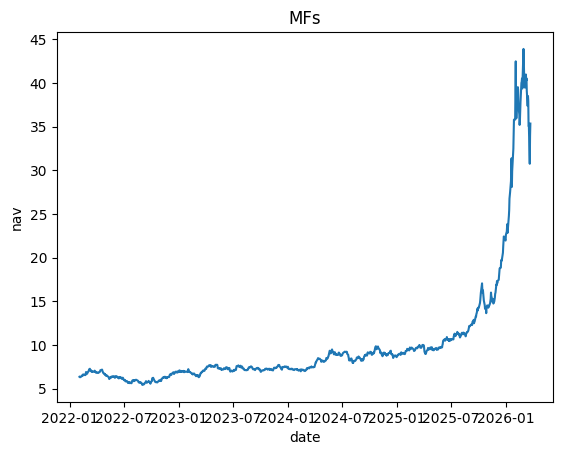

In [345]:
df = conn.execute(
    """
    SELECT sd_id, date, nav
    FROM nav_adj
    WHERE sd_id in (
149775
    )
    ORDER BY date
    """
).pl()

fig, ax = plt.subplots()
sns.lineplot(
    df,
    x="date",
    y="nav",
    ax=ax,
)
ax.set_title('MFs')
ax.set_xlabel('date')
ax.set_ylabel('nav')
